# Generative Design of RNA Polymerase Ribozymes with gRNAde

This notebook implements the gRNAde pipeline for designing functional variants of the **triplet-based RNA polymerase ribozyme (TPR)**, specifically targeting the **5TU catalytic subunit**. The notebook uses a **constraint-guided generative design** approach:

1. **Position-specific design probabilities** derived from experimental fitness landscape data guide which positions to redesign
2. **Hard constraints** fix critical functional sites
3. **Soft constraints** based on:
   - Single mutant fitness data
   - Higher-order mutant combinability scores
4. **Computational filtering** via RibonanzaNet predictions to select high-quality candidates

## Notebook Structure

1. **Setup**: Load gRNAde design model and evaluation models (RibonanzaNet, RibonanzaNetSS)
2. **Input Preparation**: Load PDB 8T2P (t1 + 5TU heterodimer from PDB: 8T2P)
3. **Constraint Definition**: Apply hard constraints (catalytic residues) and soft constraints (fitness landscapes)
4. **Generative design**: Use gRNAde to sample 1 Million variants conditioned on constraints
5. **Computational Screening**: Filter designs using RibonanzaNet SHAPE predictions and secondary structure predictions

## Usage

Generating 1 million designs requires ~12 hours on a single A100 GPU. For production runs, export this notebook as a Python script for cluster execution.

In [1]:
# Import libraries and set up the environment

import sys
sys.path.append('../../')

import dotenv
dotenv.load_dotenv("../../.env")

import os
import time
import random
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torchmetrics.functional.classification import binary_matthews_corrcoef
import torch_cluster
from torch_geometric.data import Data
from torch_geometric.utils import coalesce, dense_to_sparse, to_undirected

import lovely_tensors as lt
lt.monkey_patch()

from src.data.data_utils import *
from src.data.featurizer import *
from src.data.sec_struct_utils import dotbracket_to_adjacency
from src.models import gRNAde
from src.evaluator import (
    openknot_score_ribonanzanet,
    self_consistency_score_ribonanzanet,
    self_consistency_score_ribonanzanet_sec_struct,
    edit_distance
)
from src.data.viz_utlils import print_rna_data, draw_2d_struct, draw_2d_struct_biotite
from src.constants import (
    NUM_TO_LETTER, 
    PROJECT_PATH, 
    FILL_VALUE,
    DISTANCE_EPS,
    RNA_NUCLEOTIDES
)

from main import set_seed

from tools.ribonanzanet.network import RibonanzaNet
from tools.ribonanzanet_sec_struct.network import RibonanzaNetSS

/home/ckj24/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ckj24/.local/lib/python3.10/site-packages/Bio/Application/__init__.py:40: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [ ]:
# Set configurations

# Design probability mode for combining fitness landscape constraints
# 'sum': Add normalized single-mutant fitness + combinability scores (recommended)
# 'multiply': Multiply the two scores for more conservative constraint application
DESIGN_PROB_MODE = 'sum'

# Whether to permute sequence during generation (experimental feature)
# When True, rearranges designable positions to end of sequence during sampling
# Generally set to False for standard designs
PERMUTE = False

# Custom Featurizer for t1 + 5TU Dimer

## Why Custom Featurization?

The TPR system is a **heterodimer** consisting of:
- **t1 subunit** (135 nt): Auxiliary subunit held constant during design
- **5TU subunit** (152 nt): Catalytic subunit to be redesigned

Standard featurizers assume single-chain RNAs. This custom featurizer:
1. Handles multi-chain complexes by tracking chain identities
2. Prevents spurious edges between non-adjacent chains in the sequence graph
3. Preserves inter-chain 3D contacts (e.g., kissing loops) via spatial proximity edges
4. Ensures proper internal coordinate calculations at chain boundaries

## Key Modifications

- `chain_and_mask_residues`: Tracks which chain each residue belongs to (1=t1, 2=5TU)
- `custom_internal_vecs()`: Masks forward/backward vectors at chain boundaries to prevent artificial connectivity
- Sequence proximity edges only added within the same chain
- 3D spatial edges can span chains to capture tertiary interactions

In [3]:
class CustomRNAGraphFeaturizer:
    """Customized RNA Graph Featurizer for t1 + 5TU dimer.
    """

    def __init__(
        self,
        split="train",
        radius=4.5,
        top_k=16,
        num_rbf=32,
        num_posenc=32,
        max_num_conformers=1,
        distance_eps=DISTANCE_EPS,
        device="cpu",
    ):
        super().__init__()

        self.split = split
        self.radius = radius
        self.top_k = top_k
        self.num_rbf = num_rbf
        self.num_posenc = num_posenc
        self.max_num_conformers = max_num_conformers
        self.distance_eps = distance_eps
        self.device = device

        # nucleotide mapping: {'A': 0, 'G': 1, 'C': 2, 'U': 3, '_': 4}
        self.letter_to_num = dict(zip(RNA_NUCLEOTIDES, list(range(len(RNA_NUCLEOTIDES)))))
        self.num_to_letter = {v: k for k, v in self.letter_to_num.items()}
        self.letter_to_num["_"] = len(self.letter_to_num)  # unknown nucleotide

        # constants related to t1 + 5TU dimer
        self.t1_len = 135 
        self.fivetu_len = 152

    def __call__(self, rna, permutation=None):
        with torch.no_grad():
            # Target sequence: num_res x 1
            seq = torch.as_tensor(
                [self.letter_to_num[residue] for residue in rna["sequence"]],
                device=self.device,
                dtype=torch.long,
            )

            # Mask non-standard nucleotides: num_res x 1
            mask_seq = seq != self.letter_to_num["_"]

            # Set of coordinates: num_conf x num_res x num_bb_atoms x 3
            coords_list, sec_struct_list = get_k_random_entries(rna, k=self.max_num_conformers)
            # assert coords_list.shape[2] == 3, "Keep only 3 backbone atoms"

            # Coordinate mask: num_conf x num_res x num_bb_atoms
            mask_atoms = (coords_list == FILL_VALUE).sum(-1) == 0
            mask_residues = mask_atoms.sum(-1) != 0
            mask_confs = mask_residues.sum(-1) != 0

            # Convert to torch tensors
            coords_list = torch.as_tensor(coords_list, device=self.device, dtype=torch.float32)
            mask_atoms = torch.BoolTensor(mask_atoms)
            mask_residues = torch.BoolTensor(mask_residues) & mask_seq
            mask_confs = torch.BoolTensor(mask_confs).repeat(len(seq), 1)

            # Chain index for each residue: num_res
            chain_and_mask_residues = torch.tensor([1]*self.t1_len + [2]*self.fivetu_len, device=self.device) * mask_residues.float()

            # Node internal coordinates (scalars) and normalised vectors
            dihedrals, angles, lengths = internal_coords(coords_list, chain_and_mask_residues)
            angle_stack = torch.cat([dihedrals, angles], dim=-1)
            lengths = torch.log(lengths + self.distance_eps)
            internal_coords_feat = (
                torch.cat([torch.cos(angle_stack), torch.sin(angle_stack), lengths], dim=-1)
                * mask_residues.unsqueeze(-1).float()
            )
            internal_vecs_feat = custom_internal_vecs(coords_list, mask_atoms, len_chain_A=self.t1_len)

            if permutation is not None:
                assert len(permutation) == len(seq)
                # Map permutation index to original index
                # 0th entry in inverse_permutation ==
                # index of the 0th entry in the permuted sequence
                inverse_permutation = torch.argsort(permutation)
                # Apply the given permutation to nodes
                seq = seq[permutation]
                mask_seq = mask_seq[permutation]
                chain_and_mask_residues = chain_and_mask_residues[:, permutation]
                coords_list = coords_list[:, permutation]
                mask_atoms = mask_atoms[:, permutation]
                mask_residues = mask_residues[:, permutation]
                mask_confs = mask_confs[permutation]
                internal_coords_feat = internal_coords_feat[:, permutation]
                internal_vecs_feat = internal_vecs_feat[:, permutation]

            # Construct merged edge index
            edge_index = []
            edge_type = []

            # 3D K-nearest neighbour graph
            for _coords, _mask_atoms, _mask_residues in zip(
                coords_list, mask_atoms, mask_residues
            ):
                # K-nearest neighbour graph using centroids of each neucleotide
                _centroids = _coords.sum(1) / (
                    _mask_atoms.sum(1).unsqueeze(-1) + self.distance_eps
                )
                _edge_index = torch_cluster.knn_graph(_centroids, self.top_k)
                # Remove edges to/from masked residues (missing 3D atomic coordinates)
                _masked = torch.nonzero(~_mask_residues, as_tuple=False).squeeze(1)
                _edge_0_mask = ~_edge_index[0].unsqueeze(1).eq(_masked).any(dim=1)
                _edge_1_mask = ~_edge_index[1].unsqueeze(1).eq(_masked).any(dim=1)
                _edge_index = _edge_index[:, _edge_0_mask & _edge_1_mask]
                edge_index.append(_edge_index)
                edge_type.append(torch.ones(_edge_index.shape[1], dtype=torch.long) * 2)

            # 2D secondary structure graph
            for sec_struct in sec_struct_list:
                _sec_struct = torch.tensor(
                    dotbracket_to_adjacency(sec_struct, keep_pseudoknots=True),
                    dtype=torch.long,
                )
                if permutation is not None:
                    _sec_struct = _sec_struct[permutation][:, permutation]
                _edge_index = dense_to_sparse(_sec_struct)[0]
                edge_index.append(_edge_index)
                edge_type.append(torch.ones(_edge_index.shape[1], dtype=torch.long) * 3)

            # Sequence proximity graph
            _edge_index = []
            _edge_type = []
            for i in range(len(seq)):
                for j in range(i + 1, i + 1 + self.top_k):
                    if permutation is not None:
                        if (
                            j < len(seq)
                            and mask_seq[inverse_permutation[i]]
                            and mask_seq[inverse_permutation[j]]
                        ):
                            _i, _j = inverse_permutation[i], inverse_permutation[j]
                            # only add edge if both residues are in the same chain
                            if chain_and_mask_residues[0][_i] == chain_and_mask_residues[0][_j]:
                                _edge_index.append([_i, _j])
                                _edge_type.append(1)
                                _edge_index.append([_j, _i])
                                _edge_type.append(1)
                    else:
                        if j < len(seq) and mask_seq[i] and mask_seq[j]:
                            # only add edge if both residues are in the same chain
                            if chain_and_mask_residues[0][i] == chain_and_mask_residues[0][j]:
                                _edge_index.append([i, j])
                                _edge_type.append(1)
                                _edge_index.append([j, i])
                                _edge_type.append(1)
            edge_index.append(torch.tensor(_edge_index, dtype=torch.long).t())
            edge_type.append(torch.tensor(_edge_type, dtype=torch.long))

            # Merge edge index
            edge_index, edge_type = coalesce(
                torch.concat(edge_index, dim=1),
                torch.concat(edge_type, dim=0),
                num_nodes=len(seq),
                reduce="max",  # max edge type if multiple edges present
            )
            edge_index, edge_type = to_undirected(
                edge_index,
                edge_type,
                num_nodes=len(seq),
                reduce="max",  # max edge type if multiple edges present
            )

            # Remove edges to/from masked residues
            masked_idx = torch.nonzero(~mask_seq, as_tuple=False).squeeze(1)
            edge_0_mask = ~edge_index[0].unsqueeze(1).eq(masked_idx).any(dim=1)
            edge_1_mask = ~edge_index[1].unsqueeze(1).eq(masked_idx).any(dim=1)
            edge_index = edge_index[:, edge_0_mask & edge_1_mask]
            edge_type = edge_type[edge_0_mask & edge_1_mask]

            # Reshape: num_res x num_conf x ...
            coords_list = coords_list.permute(1, 0, 2, 3)
            internal_coords_feat = internal_coords_feat.permute(1, 0, 2)
            internal_vecs_feat = internal_vecs_feat.permute(1, 0, 2, 3)

            # Edge displacement vectors: num_edges x num_conf x num_res x 3
            edge_vectors = coords_list[edge_index[0]] - coords_list[edge_index[1]]
            edge_mask = (
                mask_atoms.permute(1, 0, 2)[edge_index[0]]
                & mask_atoms.permute(1, 0, 2)[edge_index[1]]
            )
            edge_vectors = edge_vectors * edge_mask.unsqueeze(-1).repeat(1, 1, 1, 3).float()

            # Edge lengths: num_edges x num_conf x num_res x 1
            edge_lengths = (
                torch.sqrt((edge_vectors**2).sum(dim=-1) + self.distance_eps) * edge_mask.float()
            )

            # Edge RBF features: num_edges x num_conf x num_rbf
            edge_rbf = rbf_expansion(edge_lengths, num_rbf=self.num_rbf)

            # Edge positional encodings: num_edges x num_conf x num_posenc
            if permutation is not None:
                idx_diff = permutation[edge_index[0]] - permutation[edge_index[1]]
                # # Add an artificial gap of 100 between chain A and B
                # idx_diff = torch.where(
                #     (permutation[edge_index[0]] < self.t1_len) & (permutation[edge_index[1]] >= self.t1_len),
                #     idx_diff + 100,
                #     idx_diff,
                # )
            else:
                idx_diff = edge_index[0] - edge_index[1]
                # # Add an artificial gap of 100 between chain A and B
                # idx_diff = torch.where(
                #     (edge_index[0] < self.t1_len) & (edge_index[1] >= self.t1_len),
                #     idx_diff + 100,
                #     idx_diff,
                # )
                
            edge_posenc = (
                positional_encoding(idx_diff[..., None], self.num_posenc)
                .unsqueeze_(1)
                .repeat(1, self.max_num_conformers, 1)
            )

            # Edge types as one-hot: num_edges x num_conf x num_edge_types
            edge_type = (
                F.one_hot(edge_type, num_classes=4)
                .float()
                .unsqueeze_(1)
                .repeat(1, self.max_num_conformers, 1)
            )

            node_s = internal_coords_feat
            node_v = internal_vecs_feat
            edge_s = torch.cat(
                [
                    edge_type,
                    edge_rbf,
                    edge_posenc,
                ],
                dim=-1,
            )
            edge_v = normed_vec(edge_vectors)
            node_s, node_v, edge_s, edge_v = map(
                torch.nan_to_num, (node_s, node_v, edge_s, edge_v)
            )

            data = Data(
                seq=seq,  # num_res x 1
                node_s=node_s,  # num_res x num_conf x (num_bb_atoms x 5)
                node_v=node_v,  # num_res x num_conf x (2 + (num_bb_atoms - 1)) x 3
                edge_s=edge_s,  # num_edges x num_conf x (num_bb_atoms x num_edge_types + num_rbf + num_posenc)
                edge_v=edge_v,  # num_edges x num_conf x num_bb_atoms x 3
                edge_index=edge_index,  # 2 x num_edges
                mask_seq=mask_seq,  # num_res
                mask_confs=mask_confs,  # num_res x num_conf
            )

        return data

    def featurize(self, rna, permutation=None):
        """Featurize RNA backbone from dictionary of tensors.

        Args:
            rna (dict): Raw RNA data dictionary with keys:
                - sequence (str): RNA sequence of length `num_residues`.
                - coords_list (Tensor): Backbone coordinates with shape
                    `(num_conformations, num_residues, num_bb_atoms, 3)`.
        """
        return self(rna, permutation)

    def featurize_from_pdb_file(self, pdb_filepath, permutation=None):
        """Featurize RNA backbone from PDB file.

        Args:
            pdb_filepath (str): Path to PDB file.
        """
        sequence, coords, sec_struct, _ = pdb_to_tensor(
            pdb_filepath, return_sec_struct=True, return_sasa=False
        )
        coords = get_backbone_coords(coords, sequence)
        rna = {
            "sequence": sequence,
            "coords_list": [coords],
            "sec_struct_list": [sec_struct],
        }
        return self(rna, permutation), rna

def custom_internal_vecs(X, mask_atoms, len_chain_A=135):
    # Relative displacement vectors along backbone
    # X : num_conf x num_res x num_bb_atoms x 3
    # mask_atoms: num_conf x num_res x num_bb_atoms
    p, c4p, n = X[:, :, 0], X[:, :, 1], X[:, :, 2]
    mask_p, mask_c4p, mask_n = (
        mask_atoms[:, :, 0, None],
        mask_atoms[:, :, 1, None],
        mask_atoms[:, :, 2, None],
    )
    n = (n - c4p) * mask_n * mask_c4p
    p = (p - c4p) * mask_p * mask_c4p
    forward = F.pad(c4p[:, 1:] - c4p[:, :-1], [0, 0, 0, 1]) * mask_c4p
    backward = F.pad(c4p[:, :-1] - c4p[:, 1:], [0, 0, 1, 0]) * mask_c4p
    forward[:, len_chain_A - 1] = 0  # mask fwd vector for last residue of chain A
    backward[:, len_chain_A] = 0  # mask bwd vector for first residue of chain B
    return torch.cat(
        [
            normed_vec(p).unsqueeze_(-2),
            normed_vec(n).unsqueeze_(-2),
            normed_vec(forward).unsqueeze_(-2),
            normed_vec(backward).unsqueeze_(-2),
        ],
        dim=-2,
    )

# Load gRNAde and RibonanzaNet checkpoints

In [ ]:
##################
# Design scenario
##################

# Single state or multi state design?
# - 1: single state
# - 2, 3, 5: multi state (number of states; currently unused)
max_num_conformers = 1

# random seed for reproducibility
seed = 42

# Default gRNAde model hyperparameters (configs/default.yaml; do not change unless you know what you're doing)
VERSION = 1.0
RADIUS = 0.0
TOP_K = 32
NUM_RBF = 32
NUM_POSENC = 32
NOISE_SCALE = 0.1
DROP_PROB_3D = 0.5
NODE_IN_DIM = (15, 4)
NODE_H_DIM = (128, 16)
EDGE_IN_DIM = (132, 3)
EDGE_H_DIM = (64, 4)
NUM_LAYERS = 4
DROP_RATE = 0.5
OUT_DIM = 4
DEFAULT_N_SAMPLES = 16
DEFAULT_TEMPERATURE = 0.1

In [ ]:
#########################################
# Initialise gRNAde model and featurizer
#########################################

# Set random seed
set_seed(seed)

# Set device (GPU/CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define data featurizer
print(f"Creating custom RNA graph featurizer for t1 + 5TU dimer")
featurizer = CustomRNAGraphFeaturizer(
    split = "test",
    radius = RADIUS,
    top_k = TOP_K,
    num_rbf = NUM_RBF,
    num_posenc = NUM_POSENC,
    max_num_conformers = max_num_conformers,
)
old_featurizer = RNAGraphFeaturizer(
    split = "test",
    radius = RADIUS,
    top_k = TOP_K,
    num_rbf = NUM_RBF,
    num_posenc = NUM_POSENC,
    max_num_conformers = max_num_conformers,
    noise_scale = NOISE_SCALE,
    drop_prob_3d = DROP_PROB_3D,
)
# nucleotide mapping: {'A': 0, 'G': 1, 'C': 2, 'U': 3}

# Initialise model
print(f"Initialising gRNAde model")
model = gRNAde(
    node_in_dim = NODE_IN_DIM,
    node_h_dim = NODE_H_DIM, 
    edge_in_dim = EDGE_IN_DIM,
    edge_h_dim = EDGE_H_DIM, 
    num_layers = NUM_LAYERS,
    drop_rate = DROP_RATE,
    out_dim = OUT_DIM
)
# Load model checkpoint
model_path = os.path.join(PROJECT_PATH, "checkpoints", "gRNAde_drop3d@0.75_maxlen@500.h5")
print(f"Loading gRNAde checkpoint: {model_path}")
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
# Transfer model to device in eval mode
model = model.to(device)
model.eval()
print()

#########################################
# Initialise other models for evaluation
#########################################

# Initialise RibonanzaNet for 1D self-consistency score
ribonanza_net = RibonanzaNet(
    os.path.join(PROJECT_PATH, 'tools/ribonanzanet/config.yaml'),
    os.path.join(PROJECT_PATH, 'checkpoints/ribonanzanet/ribonanzanet.pt'),
    device
)
# Transfer model to device in eval mode
ribonanza_net = ribonanza_net.to(device)
ribonanza_net.eval()
print()

# Initialise RibonanzaNetSS for 2D self-consistency score
ribonanza_net_ss = RibonanzaNetSS(
    os.path.join(PROJECT_PATH, 'tools/ribonanzanet_sec_struct/config.yaml'),
    os.path.join(PROJECT_PATH, 'checkpoints/ribonanzanet_sec_struct/ribonanzanet_ss.pt'),
    device
)
# Transfer model to device in eval mode
ribonanza_net_ss = ribonanza_net_ss.to(device)
ribonanza_net_ss.eval()
print()

Using device: cuda:0
Creating custom RNA graph featurizer for t1 + 5TU dimer
Initialising gRNAde model
Loading gRNAde checkpoint: /home/ckj24/gRNAde_2/checkpoints/gRNAde_drop3d@0.75_maxlen@500.h5

Loading RibonanzaNet checkpoint: /home/ckj24/gRNAde_2/tools/ribonanzanet/ribonanzanet.pt

Loading RibonanzaNet SS checkpoint: /home/ckj24/gRNAde_2/tools/ribonanzanet_sec_struct/ribonanzanet_ss.pt



# Prepare Input Data: Load Target Structure

## Structure Source
Load the cryo-EM structure of the TPR heterodimer from **PDB: 8T2P**:
- **8t2p_A.pdb**: t1 auxiliary subunit (135 nt) - held constant
- **8t2p_B.pdb**: 5TU catalytic subunit (152 nt) - target for redesign
- **8t2p_A-B.pdb**: Complete dimer used for full structure context

## Structure Validation
The cells below:
1. Load the 5TU subunit alone to verify sequence and secondary structure
2. Compare PDB-derived structure with RibonanzaNetSS predictions (quality check)
3. Load the full dimer for design (preserves inter-chain kissing loop interactions)

In [6]:
##############################
# 5TU subunit - chain B only
##############################

fivetu_pdb_filepath = "structures/8t2p_B.pdb"

fivetu_featurized_data, fivetu_raw_data = old_featurizer.featurize_from_pdb_file(fivetu_pdb_filepath)
pred_sec_struct = ribonanza_net_ss.predict(fivetu_raw_data['sequence'])[1][0]

print_rna_data(fivetu_raw_data)

print("Featurized PyG Data object:\n\t", fivetu_featurized_data)

sequence:
	GGAUCUUCUCGAUCUAACAAAAAAGACAAAUCUGCCACAAAGCUUGAGAGCAUCUUCGGAUGCAGAGGCGGCAGCCUUCGGUGGCGCGAUAGCGCCAACGUUCUCAACUAUGACACGCAAAACGCGUGCUCCGUUGAAUGGAGUUUAUCAUG
coords_list:
	tensor[152, 3, 3] n=1368 (5.3Kb) x∈[-42.430, 62.417] μ=-0.046 σ=18.992
sec_struct_list:
	((((.......))))................[[[[[.....(.(((((((((((....))))).((((.]]]]]))))(((((((((....))))))))).)))))))(((((((((((...))))))(((((.....)))))....)))))
Featurized PyG Data object:
	 Data(edge_index=[2, 10544], seq=[152], node_s=[152, 1, 15], node_v=[152, 1, 4, 3], edge_s=[10544, 1, 132], edge_v=[10544, 1, 3, 3], mask_seq=[152], mask_confs=[152, 1])


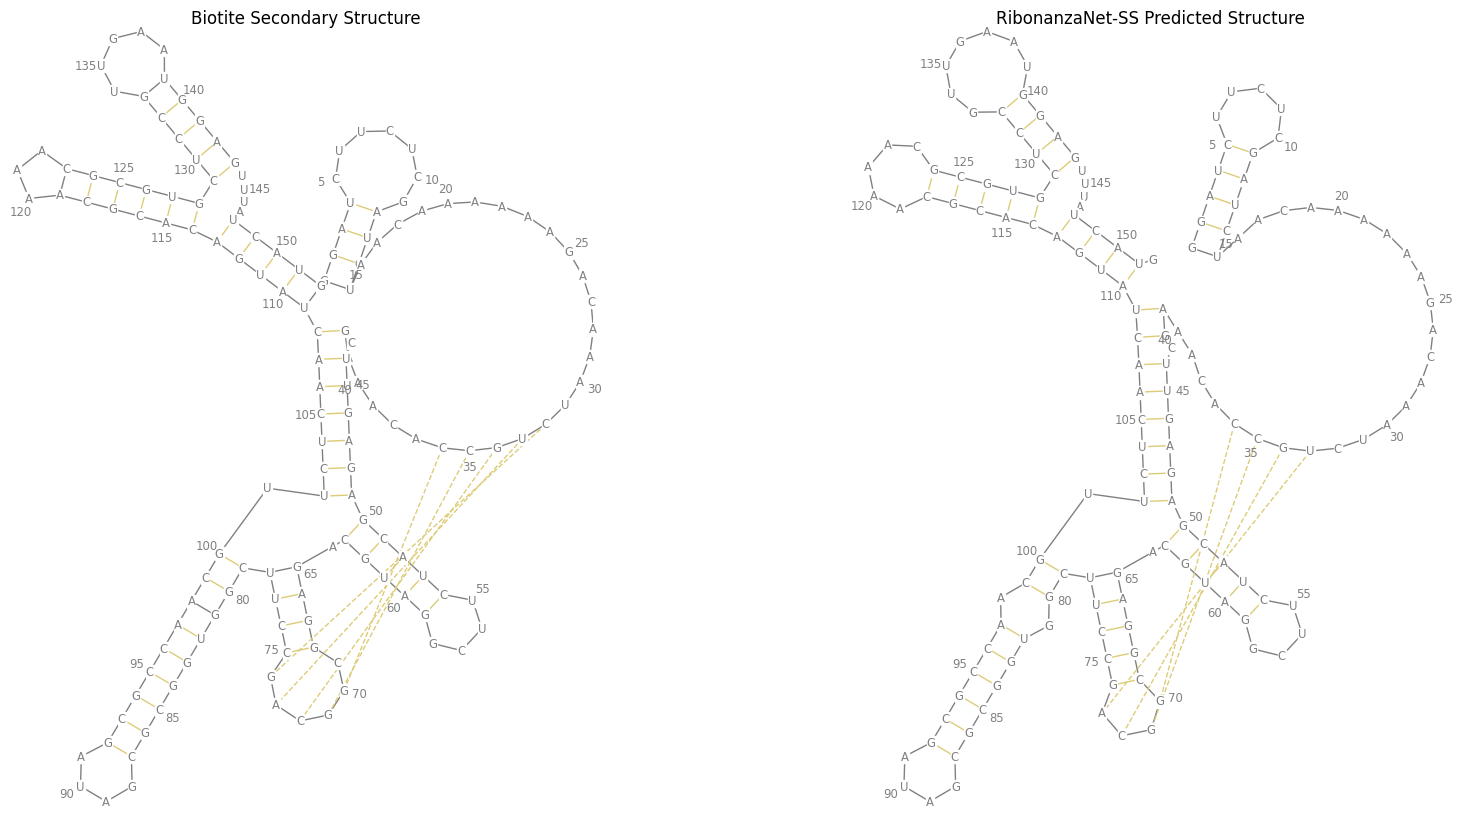

In [7]:
plt.figure(figsize=(20, 10))
ax1 = plt.subplot(1, 2, 1)
plt.title('Biotite Secondary Structure')
# draw_2d_struct(fivetu_raw_data['sequence'], fivetu_raw_data['sec_struct_list'][0], ax=ax1, line=True)
draw_2d_struct_biotite(ax1, fivetu_raw_data['sequence'], fivetu_raw_data['sec_struct_list'][0])
ax2 = plt.subplot(1, 2, 2)
plt.title('RibonanzaNet-SS Predicted Structure')
# draw_2d_struct(fivetu_raw_data['sequence'], pred_sec_struct, ax=ax2, line=True)
draw_2d_struct_biotite(ax2, fivetu_raw_data['sequence'], pred_sec_struct)
plt.show()

In [8]:
t1_seq = 'GACCAAUCUGCCCUCAGAGCUCGAGAACAUCUUCGGAUGCAGAGGAGGCAGGCUUCGGUGGCGCGAUAGCGCCAACGUCCUCAACCUCCAAUGCAUCCCACCACAUGAUGAUGCCUGAAGAGCCUUGGUUUUUUG'
print("T1 sequence:  ", t1_seq)

fivetu_seq = 'GGAUCUUCUCGAUCUAACAAAAAAGACAAAUCUGCCACAAAGCUUGAGAGCAUCUUCGGAUGCAGAGGCGGCAGCCUUCGGUGGCGCGAUAGCGCCAACGUUCUCAACUAUGACACGCAAAACGCGUGCUCCGUUGAAUGGAGUUUAUCAUG'
print("5TU sequence: ", fivetu_seq)

assert fivetu_seq == fivetu_raw_data['sequence']

target_sec_struct = fivetu_raw_data['sec_struct_list'][0]

print("Target:   ", target_sec_struct)
print("Predicted:", pred_sec_struct)
print("Correlation: ",
    float(binary_matthews_corrcoef(
        torch.tensor(
            dotbracket_to_adjacency(pred_sec_struct, keep_pseudoknots=True)
        ),
        torch.tensor(
            dotbracket_to_adjacency(target_sec_struct, keep_pseudoknots=True)
        )
    ))
)

T1 sequence:   GACCAAUCUGCCCUCAGAGCUCGAGAACAUCUUCGGAUGCAGAGGAGGCAGGCUUCGGUGGCGCGAUAGCGCCAACGUCCUCAACCUCCAAUGCAUCCCACCACAUGAUGAUGCCUGAAGAGCCUUGGUUUUUUG
5TU sequence:  GGAUCUUCUCGAUCUAACAAAAAAGACAAAUCUGCCACAAAGCUUGAGAGCAUCUUCGGAUGCAGAGGCGGCAGCCUUCGGUGGCGCGAUAGCGCCAACGUUCUCAACUAUGACACGCAAAACGCGUGCUCCGUUGAAUGGAGUUUAUCAUG
Target:    ((((.......))))................[[[[[.....(.(((((((((((....))))).((((.]]]]]))))(((((((((....))))))))).)))))))(((((((((((...))))))(((((.....)))))....)))))
Predicted: (((((.....))))).................((((....[[.[[[[[[(((((....))))).[[[[[))))]]]]]((.((((((....)))))).)).]]]]]]]](((((((((.....)))))((((.......))))....)))).
Correlation:  0.918209433555603


In [9]:
# Create raw data object from PDB files
pdb_filepath = f"structures/8t2p_A-B.pdb"

featurized_data, raw_data = featurizer.featurize_from_pdb_file(pdb_filepath)
featurized_data.to(device)

assert raw_data['sequence'] == t1_seq + fivetu_seq
assert raw_data['sequence'][:len(t1_seq)] == t1_seq
assert raw_data['sequence'][len(t1_seq):] == fivetu_seq

print_rna_data(raw_data)

print("Featurized PyG Data object:\n\t", featurized_data)

sequence:
	GACCAAUCUGCCCUCAGAGCUCGAGAACAUCUUCGGAUGCAGAGGAGGCAGGCUUCGGUGGCGCGAUAGCGCCAACGUCCUCAACCUCCAAUGCAUCCCACCACAUGAUGAUGCCUGAAGAGCCUUGGUUUUUUGGGAUCUUCUCGAUCUAACAAAAAAGACAAAUCUGCCACAAAGCUUGAGAGCAUCUUCGGAUGCAGAGGCGGCAGCCUUCGGUGGCGCGAUAGCGCCAACGUUCUCAACUAUGACACGCAAAACGCGUGCUCCGUUGAAUGGAGUUUAUCAUG
coords_list:
	tensor[287, 3, 3] n=2583 (10Kb) x∈[-63.343, 68.230] μ=0.026 σ=26.115
sec_struct_list:
	<(((((..((((.((((.((.[[[[[[(((((((((((((((.(((((.(((.(.(((((((((..{{)))))))))))))...))))).)))))))))...).).))))..)))))).).)))))))....>).((((.]]]]]]))))................[[[[[.....(.(((((((((((....))))).((((.]]]]]))))(((((((((..}}))))))))).)))))))(((((((((((...))))))(((((.....)))))....)))))
Featurized PyG Data object:
	 Data(edge_index=[2, 20582], seq=[287], node_s=[287, 1, 15], node_v=[287, 1, 4, 3], edge_s=[20582, 1, 132], edge_v=[20582, 1, 3, 3], mask_seq=[287], mask_confs=[287, 1])


# Prepare Design Constraints from Fitness Landscape Data

Position-specific design probabilities guide gRNAde to explore productive regions of sequence space while preserving critical functional sites. These constraints are derived from **experimental fitness landscape data** from directed evolution experiments.

1. Single-Mutant Fitness (`max_fitness_array.npy`)
    - Measures the maximum fitness achieved by single point mutations at each position
    - High fitness positions → more designable (can tolerate mutations)
    - Low fitness positions → less designable (functionally constrained)
    - Binned into 4 levels: 0 (critical), 1 (constrained), 2 (moderate), 3 (highly designable)

2. Higher-Order Combinability (`combinability_array.npy`)
    - Measures how well mutations at a position combine with other mutations
    - High combinability → position participates in many successful double/triple mutants
    - Indicates positions that can be mutated without breaking compensatory interactions
    - Binned into 4 levels based on number of successful combinations

## Combining Constraints
Design probability = `(fitness_bin + combinability_bin) / 6.0` when `DESIGN_PROB_MODE='sum'`
- Range: 0.0 (never design) to 1.0 (always design)
- Balances local fitness effects with global epistatic interactions

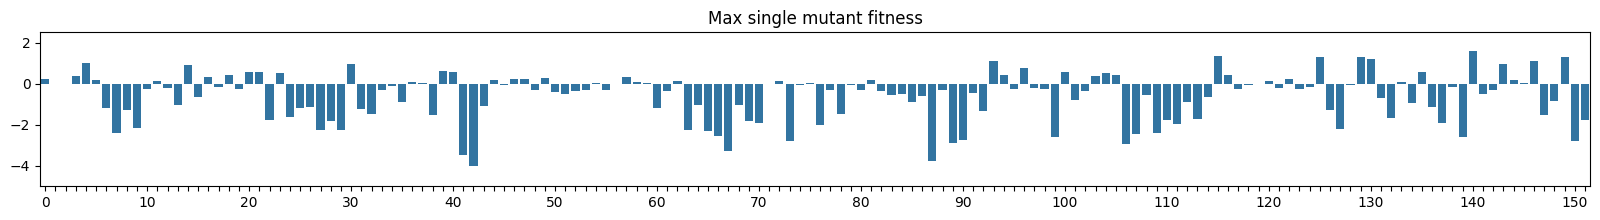

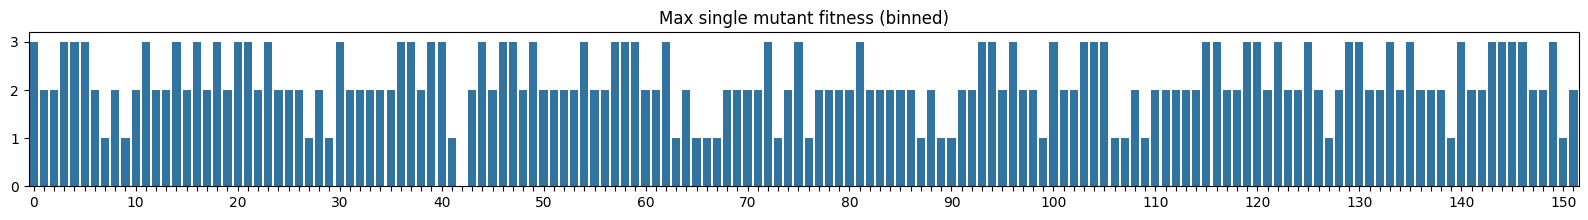

In [10]:
# Max single mutant fitness
fivetu_max_fitness = np.load("fitness_landscape_constraints/max_fitness_array.npy")

plt.figure(figsize=(20, 2))
sns.barplot(x=np.arange(len(fivetu_max_fitness)), y=fivetu_max_fitness)
plt.xticks(
    np.arange(len(fivetu_raw_data['sequence'])), 
    [f"{i if i % 10 == 0 else ' '}" for i in range(len(fivetu_raw_data['sequence']))]
)
plt.title("Max single mutant fitness")
plt.ylim(-5, 2.5)
plt.show()

# bin fivetu_max_fitness
fivetu_max_fitness_binned = np.zeros_like(fivetu_max_fitness)
fivetu_max_fitness_binned[fivetu_max_fitness > 0] = 3
fivetu_max_fitness_binned[(fivetu_max_fitness <= 0) & (fivetu_max_fitness > -2.0)] = 2
fivetu_max_fitness_binned[(fivetu_max_fitness <= -2.0) & (fivetu_max_fitness > -4.0)] = 1

plt.figure(figsize=(20, 2))
sns.barplot(x=np.arange(len(fivetu_max_fitness_binned)), y=fivetu_max_fitness_binned)
plt.xticks(
    np.arange(len(fivetu_raw_data['sequence'])), 
    [f"{i if i % 10 == 0 else ' '}" for i in range(len(fivetu_raw_data['sequence']))]
)
plt.title("Max single mutant fitness (binned)")
plt.ylim(0, 3.2)
plt.show()

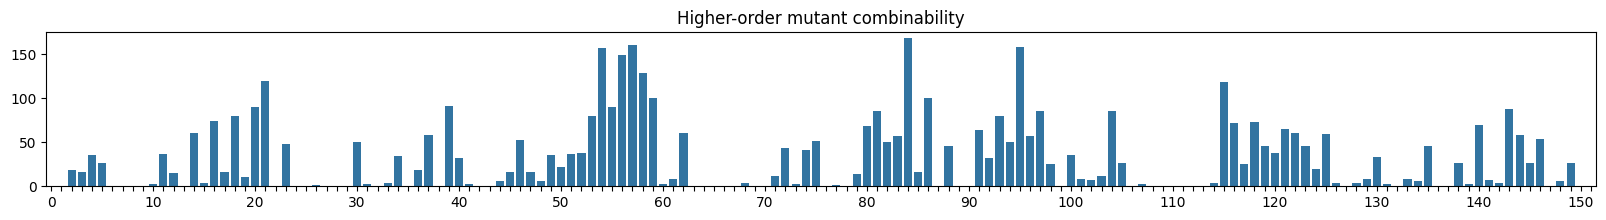

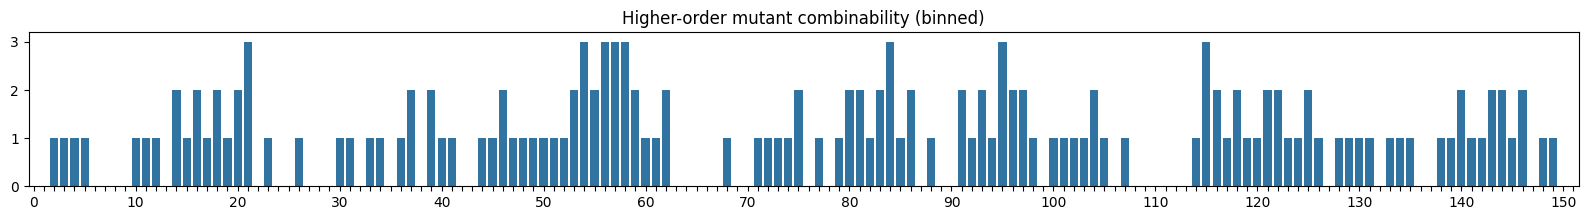

In [11]:
# Higher-order mutant combinability
fivetu_combinability = np.load("fitness_landscape_constraints/combinability_array.npy")

plt.figure(figsize=(20, 2))
sns.barplot(x=np.arange(len(fivetu_combinability)), y=fivetu_combinability)
plt.xticks(
    np.arange(len(fivetu_raw_data['sequence'])), 
    [f"{i if i % 10 == 0 else ' '}" for i in range(len(fivetu_raw_data['sequence']))]
)
plt.title("Higher-order mutant combinability")
plt.ylim(0, 175)
plt.show()

# bin fivetu_combinability
fivetu_combinability_binned = np.zeros_like(fivetu_combinability)
fivetu_combinability_binned[fivetu_combinability > 100] = 3
fivetu_combinability_binned[(fivetu_combinability <= 100) & (fivetu_combinability > 50)] = 2
fivetu_combinability_binned[(fivetu_combinability <= 50) & (fivetu_combinability > 0)] = 1

plt.figure(figsize=(20, 2))
sns.barplot(x=np.arange(len(fivetu_combinability_binned)), y=fivetu_combinability_binned)
plt.xticks(
    np.arange(len(fivetu_raw_data['sequence'])), 
    [f"{i if i % 10 == 0 else ' '}" for i in range(len(fivetu_raw_data['sequence']))]
)
plt.title("Higher-order mutant combinability (binned)")
plt.ylim(0, 3.2)
plt.show()

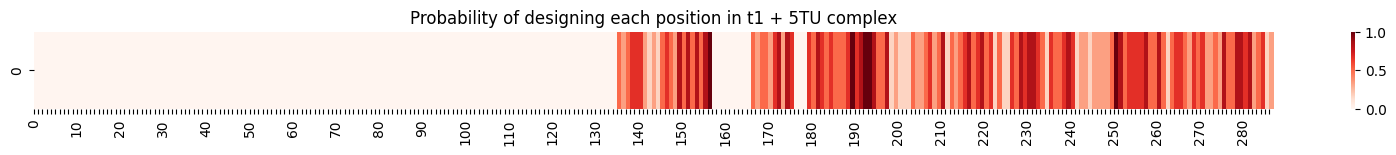

In [12]:
# Array to store the probability of designing each position
# - 0.0: always fixed
# - 1.0: always designable
pos_to_hard_constraint = np.array([1.0] * len(raw_data['sequence']))
pos_to_design_prob = np.array([1.0] * len(raw_data['sequence']))

# Set the probability of designing the t1 subunit to 0.0 --> all positions are fixed
pos_to_hard_constraint[:len(t1_seq)] = 0.0
pos_to_design_prob[:len(t1_seq)] = 0.0

# Add max single mutant fitness as well as combinability constraints to 5TU
for i, (fitness, combinability) in enumerate(zip(fivetu_max_fitness_binned, fivetu_combinability_binned)):
    if DESIGN_PROB_MODE == "sum":
        pos_to_design_prob[len(t1_seq) + i] = (fitness + combinability) / 6.0
    elif DESIGN_PROB_MODE == "multiply":
        pos_to_design_prob[len(t1_seq) + i] = (fitness * combinability) / 9.0 + 0.01
    else:
        raise ValueError("Invalid design_prob_mode")

# Set the probability of 5TU catalytic nucleotides to 0.0 --> all positions are fixed
# Catalytic site: positions 41-43 in 5TU sequence
pos_to_hard_constraint[len(t1_seq) + 41:len(t1_seq) + 43 + 1] = 0.0
pos_to_design_prob[len(t1_seq) + 41:len(t1_seq) + 43 + 1] = 0.0
# Template binding nts: positions 22-24 in 5TU sequence
pos_to_hard_constraint[len(t1_seq) + 22:len(t1_seq) + 24 + 1] = 0.0
pos_to_design_prob[len(t1_seq) + 22:len(t1_seq) + 24 + 1] = 0.0
# Triple helix-forming adenosines: positions 25-30 in 5TU sequence
pos_to_hard_constraint[len(t1_seq) + 25:len(t1_seq) + 30 + 1] = 0.0
pos_to_design_prob[len(t1_seq) + 25:len(t1_seq) + 30 + 1] = 0.0

# Plot heatmap of design probabilities
plt.figure(figsize=(20, 1))
sns.heatmap(pos_to_design_prob.reshape(1, -1), cmap='Reds')
plt.xticks(
    np.arange(len(raw_data['sequence'])), 
    [f"{i if i % 10 == 0 else ' '}" for i in range(len(raw_data['sequence']))]
)
plt.title("Probability of designing each position in t1 + 5TU complex")
plt.show()

## Apply Hard and Soft Constraints

### Hard Constraints (Always Fixed)
These positions are **never** mutated regardless of fitness data:
1. **t1 subunit** (positions 0-134): Entire auxiliary chain held constant
2. **Catalytic residues** (5TU positions 41-43): Essential for polymerase chemistry
3. **Template binding sites** (5TU positions 22-24): Required for substrate recognition  
4. **Triple helix adenosines** (5TU positions 25-30): Form critical structural motif

### Soft Constraints (Probabilistic)
For all other 5TU positions, design probability is computed from fitness landscape:
- At each generation round, each position is independently chosen to be designable or fixed based on its probability
- Higher probability → more likely to be included in the designable set
- This stochastic approach explores diverse constraint patterns across the design library

### Visualization
The heatmap shows final design probabilities across the full 287 nt sequence (t1 + 5TU).

In [13]:
# Create logit bias for hard constraints

partial_seq = []
for i in range(len(raw_data['sequence'])):
    if pos_to_hard_constraint[i] == 0.0:
        partial_seq.append(raw_data['sequence'][i])
    else:
        partial_seq.append("_")
partial_seq = "".join(partial_seq)
print("Hard constraints partial sequence:\n", partial_seq)

# create logit bias matrix
_partial_seq = []
for residue in partial_seq:
    if residue in featurizer.letter_to_num.keys():
        # fixed nucleotide
        _partial_seq.append(featurizer.letter_to_num[residue])
    else:
        # designable position
        _partial_seq.append(len(featurizer.letter_to_num.keys()))
_partial_seq = torch.as_tensor(_partial_seq, device=device, dtype=torch.long)
# convert to one-hot and create bias matrix used during sampling
hard_logit_bias = F.one_hot(_partial_seq, num_classes=model.out_dim+1).float()
# create final logit_bias matrix for masked sampling
hard_logit_bias = hard_logit_bias[:, :-1] * 100.0
print(hard_logit_bias)

Hard constraints partial sequence:
 GACCAAUCUGCCCUCAGAGCUCGAGAACAUCUUCGGAUGCAGAGGAGGCAGGCUUCGGUGGCGCGAUAGCGCCAACGUCCUCAACCUCCAAUGCAUCCCACCACAUGAUGAUGCCUGAAGAGCCUUGGUUUUUUG______________________AAGACAAAU__________GCU____________________________________________________________________________________________________________
tensor[287, 4] n=1148 (4.5Kb) x∈[0., 100.000] μ=12.805 σ=33.429 cuda:0


# Generate Design Library with Computational Filtering

## Generation Strategy

This cell implements the complete gRNAde pipeline from Figure 1 of the paper:

### A. Generation Stage (per batch)
1. **Sample soft constraints**: Stochastically select designable positions based on fitness probabilities
2. **Create combined logit bias**: Merge hard + soft constraints
3. **Sample temperature**: Randomize between 0.1-1.5 to encourage sequence diversity
4. **Generate sequences**: Use gRNAde to create `n_samples` designs per batch

### B. Screening Stage  
For each generated sequence:
1. **SHAPE self-consistency** (`sc_score_ribonanzanet`): MAE between predicted and target reactivity
   - Lower is better; threshold ~0.15 for high-quality designs
2. **2D structure self-consistency** (`sc_score_ribonanzanet_ss`): MCC for secondary structure match
   - Higher is better; indicates correct base pairing

### C. Selection Stage
- Designs are saved to CSV and duplicates are removed at the end of generation
- Each design includes full metadata: sequence, edit distance, perplexity, self-consistency scores
- Target: Generate ~1M total designs, optionally filtering to top `n_pass` candidates

## Output Format
CSV columns: `fasta_desc, sequence, model, seed, temperature, edit_dist, perplexity, sc_score_ribonanzanet, sc_score_ribonanzanet_ss`


In [ ]:
# Total number of samples to generate
total_samples = 1_000_000

# Number of designed samples (per batch)
n_samples = 256

# Partial featurization / loading from PDB file
sequence, coords, sec_struct, _ = pdb_to_tensor(
    pdb_filepath, return_sec_struct=True, return_sasa=False
)
coords = get_backbone_coords(coords, sequence)
raw_data = {
    "sequence": sequence,
    "coords_list": [coords],
    "sec_struct_list": [sec_struct],
}

# Create output directory
current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"designs/"
os.makedirs(output_dir, exist_ok=True)
output_file = f"{output_dir}/gRNAde_{current_datetime}.csv"
with open(output_file, 'w') as f_out:
    f_out.write("fasta_desc,sequence,model,seed,temperature,edit_dist,perplexity,sc_score_ribonanzanet,sc_score_ribonanzanet_ss\n")

# collate designed sequences for saving to csv
designs = []
t = tqdm(range(total_samples // n_samples))
for _ in t:
    t.set_description(f"Total designs: {len(designs)}")

    # Set temperature and seed
    temperature = np.random.uniform(0.1, 1.5)
    seed = random.randint(0, 9999)
    set_seed(seed)

    # Add soft constraints to the design using pos_to_design_prob
    partial_seq = []
    for i in range(len(raw_data['sequence'])):
        if pos_to_design_prob[i] == 0.0:
            partial_seq.append(raw_data['sequence'][i])
        elif np.random.rand() < pos_to_design_prob[i]:
            partial_seq.append("_")
        else:
            partial_seq.append(raw_data['sequence'][i])
    partial_seq = "".join(partial_seq)
    
    # create soft logit bias matrix
    _partial_seq = []
    for residue in partial_seq:
        if residue in featurizer.letter_to_num.keys():
            # fixed nucleotide
            _partial_seq.append(featurizer.letter_to_num[residue])
        else:
            # designable position
            _partial_seq.append(len(featurizer.letter_to_num.keys()))
    _partial_seq = torch.as_tensor(_partial_seq, device=device, dtype=torch.long)
    # convert to one-hot and create bias matrix used during sampling
    logit_bias = F.one_hot(_partial_seq, num_classes=model.out_dim+1).float()
    # create final logit_bias matrix for masked sampling
    logit_bias = logit_bias[:, :-1] * torch.rand(len(logit_bias)).unsqueeze(1).to(device) * 10.0
    # add hard constraints
    logit_bias += hard_logit_bias

    if PERMUTE == True:
        # Permute partial sequence and featurize so that designable positions are at the end
        permutation = []
        for i in range(len(partial_seq)):
            if partial_seq[i] != "_":
                permutation.append(i)
        for i in range(len(partial_seq)):
            if partial_seq[i] == "_":
                permutation.append(i)
        permutation = torch.tensor(permutation, dtype=torch.long)
        featurized_data = featurizer.featurize(raw_data, permutation)
        featurized_data.to(device)
        logit_bias = logit_bias[permutation]
    else:
        featurized_data = featurizer.featurize(raw_data)
        featurized_data.to(device)

    # sample n_samples from model for single data point: n_samples x seq_len
    samples, logits = model.sample(
        featurized_data, 
        n_samples, 
        temperature, 
        logit_bias=logit_bias,
        return_logits=True
    )

    if PERMUTE == True:
        # unpermute samples and logits
        _samples = torch.zeros_like(samples)
        _logits = torch.zeros_like(logits)
        for i, idx in enumerate(permutation):
            _samples[:, idx] = samples[:, i]
            _logits[:, idx] = logits[:, i]
        samples = _samples
        logits = _logits

    # remove t1_seq from samples and logits
    samples = samples[:, len(t1_seq):].contiguous()
    logits = logits[:, len(t1_seq):].contiguous()

    # perplexity per sample: n_samples x 1
    n_nodes = logits.shape[1]
    perplexity = (
        torch.exp(
            F.cross_entropy(
                logits.view(n_samples * n_nodes, model.out_dim),
                samples.view(n_samples * n_nodes).long(),
                reduction="none",
            )
            .view(n_samples, n_nodes)
            .mean(dim=1)
        )
        .cpu()
        .numpy()
    )

    # SHAPE self-consistency score per sample: n_samples x 1
    sc_score_ribonanzanet = self_consistency_score_ribonanzanet(
        samples.cpu().numpy(),
        fivetu_raw_data["sequence"], 
        fivetu_featurized_data.mask_seq.cpu().numpy(),
        ribonanza_net,
    )

    # 2D self-consistency score per sample: n_samples x 1
    sc_score_ribonanzanet_ss = self_consistency_score_ribonanzanet_sec_struct(
        samples.cpu().numpy(),
        target_sec_struct,
        fivetu_featurized_data.mask_seq.cpu().numpy(),
        ribonanza_net_ss,
    )

    # collate designed sequences in fasta and csv format
    with open(output_file, 'a') as f_out:
        for zipped in zip(samples.cpu().numpy(), perplexity, sc_score_ribonanzanet, sc_score_ribonanzanet_ss):
            seq, perp, sc_score_rnet, sc_score_rnetss = zipped
            seq = "".join([NUM_TO_LETTER[num] for num in seq])
            edit_dist = edit_distance(seq, fivetu_raw_data['sequence'])
            design = [
                f"{os.path.split(model_path)[-1]} seed={seed} temperature={temperature:.4f} edit_dist={edit_dist} perplexity={perp:.4f} sc_score_ribonanzanet={sc_score_rnet:.4f} sc_score_ribonanzanet_ss={sc_score_rnetss:.4f}",
                seq, os.path.split(model_path)[-1], seed, temperature, edit_dist, perp, sc_score_rnet, sc_score_rnetss
            ]
            designs.append(design)
            f_out.write(",".join(map(str, design)) + "\n")

    if len(designs) >= n_pass:
        break

In [ ]:
# Load all designs and remove duplicates
all_designs_df = pd.read_csv(f"designs/gRNAde_{current_datetime}.csv")
print("Total designs:", len(all_designs_df))
all_designs_df = all_designs_df.drop_duplicates(subset="sequence")
print("Unique designs:", len(all_designs_df))
# overwrite csv file with unique designs only
all_designs_df.to_csv(f"designs/gRNAde_{current_datetime}.csv", index=False)